# Running FORCE Level 2 and Time Series Analysis

### Purpose

The [Earth Observation Application Package (EOAP)](https://docs.ogc.org/bp/20-089r1.html) and surrounding tools implemented in the [`apex-force-openeo`](https://github.com/bcdev/apex-force-openeo) make it possible to use the [FORCE](https://force-eo.readthedocs.io/en/latest/) EO processing engine on the [Copernicus Data Space Ecosystem (CDSE)](https://dataspace.copernicus.eu/) using the [openEO](https://openeo.dataspace.copernicus.eu/) API.
This notebook uses `pystac_client` to make a STAC query to determine input products. This is a valid alternative to the `query_stac` process in OpenEO, especially until it is supported on the production environment.

> This notebook serves to showcase how to combine FORCE level 2 and FORCE Time Series Analysis on CDSE openEO. For a more detailed discussion on how to run FORCE level 2, have a look at the `run-level2-and-download` examples.

Please note that this is neither a tutorial for FORCE nor for openEO, please have a look at the Furhter Reading section below, if you are unfamiliar with either. The basic openEO client operations will be explained, FORCE will be used without further explanation. Please refer to the [FORCE documentation](https://force-eo.readthedocs.io/en/latest) for the [level 2 processing system](https://force-eo.readthedocs.io/en/latest/components/lower-level/level2/) and the [Time Series Analysis (TSA) module](https://force-eo.readthedocs.io/en/latest/components/higher-level/tsa/index.html#time-series-analysis) and to learn more.


### Prerequisites

In order to run this notebook, you need to have a CDSE account and sufficient openEO credits to run the jobs. Please note that CDSE provides a contigent of free credits each month, so you should be able to run the notebook if you haven't used up your credits with no additional cost.

> At the time of writing (2026-04-20) the query process `query_stac` requires an account for the staging deployment of the openEO backend. However, it should be available on the production deployment soon.

### Content

1. Connect to OpenEO backend
2. Make a query to the CDSE STAC catalog to determine input products
3. Run the FORCE l2ps on CDSE using OpenEO and the FORCE EOAP
4. Download processed products
5. Visualize the results

### Citation and Acknowledgement

When using the FORCE processing engine, please make sure to properly [cite and acknowledge](https://force-eo.readthedocs.io/en/latest/policy/citation.html)
the software and its related [scientific publications](https://force-eo.readthedocs.io/en/latest/refs.html#refs) .
The implementation as EOAP was performed in the context of ESA's [APEx](https://apex.esa.int/) initiative.

### Further reading

**APEx**

1. [Project website](https://apex.esa.int/)
2. [Documentation Portal](https://esa-apex.github.io/apex_documentation/)

**FORCE**

1. [Documentation](https://force-eo.readthedocs.io/en/latest/index.html)
1. [Level 2 processing system](https://force-eo.readthedocs.io/en/latest/components/lower-level/level2/)
1. [Citation and acknowledgement](https://force-eo.readthedocs.io/en/latest/policy/citation.html)


**openEO**

1. [openEO on CDSE](https://documentation.dataspace.copernicus.eu/APIs/openEO/openEO.html)
1. [Credit Usage on CDSE](https://documentation.dataspace.copernicus.eu/APIs/openEO/credit_usage.html)
1. [openEO project website](https://openeo.org/)
1. [openEO Python Client documentation](https://open-eo.github.io/openeo-python-client/)

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import openeo
import contextily
import shapely
import pystac
import pystac_client
import matplotlib.pyplot as plt
import rioxarray

import force_tsa_example_utils as utils

### Area of Interest

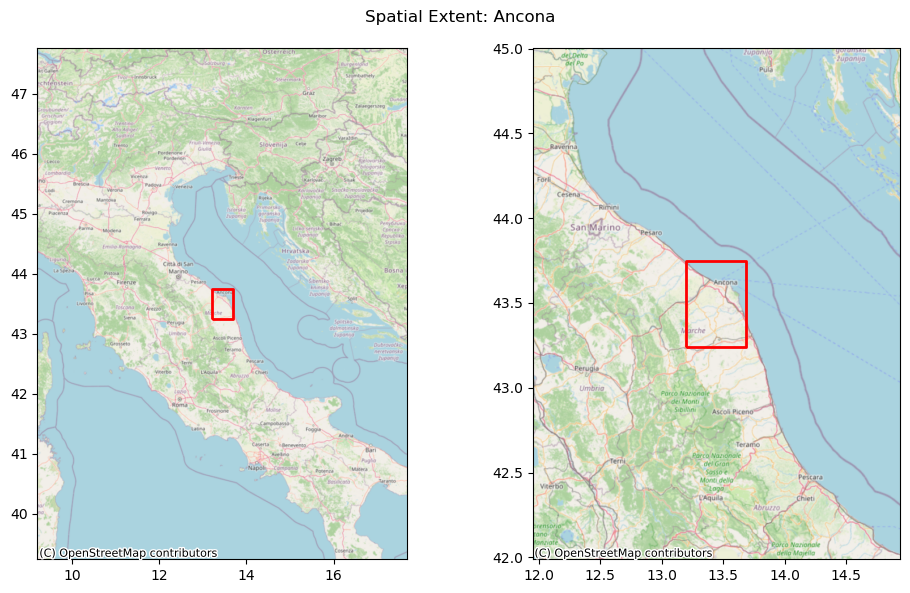

In [3]:
w,s,e,n = 13.2, 43.239, 13.688, 43.75
spatial_extent = { "west": w, "south": s, "east": e, "north": n}
aoi_name = "Ancona"
temporal_extent=["2026-04-19", "2026-04-20"]

utils.plot_area_of_interest(
    w=w,
    s=s,
    e=e,
    n=n,
    large_context=4,
    figsize=(10, 6),
    title=f"Spatial Extent: {aoi_name}"
)

### Connect to the OpenEO backend

In [4]:
backend_url = "openeo-staging.dataspace.copernicus.eu"
connection = openeo.connect(backend_url).authenticate_oidc()

Authenticated using refresh token.


### Query the CDSE STAC catalog

In [5]:
L1C_COLLECTION_URL = "https://stac.dataspace.copernicus.eu/v1/collections/sentinel-2-l1c"

client = pystac_client.Client.open("https://stac.dataspace.copernicus.eu/v1")
search = client.search(
    max_items=2,
    collections=["sentinel-2-l1c"],
    bbox=[w, s, e, n]
)
item_collection = search.item_collection()

print("Found items:")
for item in search.items():
    print(item.id)


Found items:
S2B_MSIL1C_20260419T100019_N0512_R122_T33TUJ_20260419T133413
S2B_MSIL1C_20260419T100019_N0512_R122_T33TUH_20260419T133413


### Running FORCE level 2 (l2ps)

We need to tell FORCE on which products to run. The processor will automatically download the necessary files.
As usual in openEO, we can chain processes. In this case, we can connect the query directly to FORCE level2, without evaluating it.
Note that we use the openEO process graph `query_pg` and not the query results as a parameter.

#### Note:

**You will be able to use a dedicated process `force_level2` instead of `run_cwl_to_stac` which will make it unnecessary to explicitly pass the CWL document in the future.
Until this process is available on the CDSE openEO backend, `run_cwl_to_stac` can be used.**

#### openEO

You can track the progress of your job by logging into the openEO web interface 

Alternatively, in a separate Python shell / notebook, you can run the following snippet to get access to the logs as a Python list.
You can find out the job id from the next cell below.

Please be aware that the output from CWL jobs is not optimized for openEO logs, so the logs may look quite messy and fragmented. 
However, they can be a valuable source of information to debug issues.

```Python
connection = ... # connect to the same backend
l2_job = connection.job(<job-id>)
l2_logs = l2_job.logs()
print("\n".join(l2_logs[:20]))
```

In [7]:
cwl_text = Path("force-level2.cwl").read_text()
context = dict(
    stac_document=item_collection.to_dict(),
)

stac_resource = openeo.rest.stac_resource.StacResource(
    graph=openeo.internal.graph_building.PGNode(
        process_id="run_cwl_to_stac",
        arguments={
            "cwl_url": cwl_text,
            "context": context,
        }
    ),
    connection=connection,
)
l2_job = stac_resource.create_job(title=f"FORCE level 2 - {aoi_name}")
print(f"Job id: '{l2_job.job_id}'")
l2_job.start_and_wait()

Job id: 'j-26042013371845f3a9d308cdd50139c1'
0:00:00 Job 'j-26042013371845f3a9d308cdd50139c1': send 'start'
0:00:14 Job 'j-26042013371845f3a9d308cdd50139c1': created (progress 0%)
0:00:19 Job 'j-26042013371845f3a9d308cdd50139c1': created (progress 0%)
0:00:26 Job 'j-26042013371845f3a9d308cdd50139c1': created (progress 0%)
0:00:34 Job 'j-26042013371845f3a9d308cdd50139c1': created (progress 0%)
0:00:44 Job 'j-26042013371845f3a9d308cdd50139c1': created (progress 0%)
0:00:57 Job 'j-26042013371845f3a9d308cdd50139c1': running (progress 8.1%)
0:01:12 Job 'j-26042013371845f3a9d308cdd50139c1': running (progress 10.3%)
0:01:31 Job 'j-26042013371845f3a9d308cdd50139c1': running (progress 12.8%)
0:01:56 Job 'j-26042013371845f3a9d308cdd50139c1': running (progress 15.8%)
0:02:26 Job 'j-26042013371845f3a9d308cdd50139c1': running (progress 19.2%)
0:03:03 Job 'j-26042013371845f3a9d308cdd50139c1': running (progress 23.1%)
0:03:50 Job 'j-26042013371845f3a9d308cdd50139c1': running (progress 27.4%)
0:04:49 

<BatchJob job_id='j-26042013371845f3a9d308cdd50139c1'>

## Extracting Tiles from the result

In [8]:
item = pystac.read_file(item_url)
tiles = set([k.split(".")[1] for k in item.assets.keys() if k.endswith("BOA")])
tile_x = set(int(tile[1:5]) for tile in tiles)
tile_y = set(int(tile[7:]) for tile in tiles)
tile_x, tile_y

NameError: name 'item_url' is not defined

## Running Force Time Series Analysis (TSA)

In [ ]:
# process parameters
context = dict(
    stac_url=item_url,
    date_range=("2026-04-06", "2026-04-09"),
    x_tile_range=[min(tile_x), max(tile_x)],
    y_tile_range=[min(tile_y), max(tile_y)],
    stm=["AVG"],
    output_stm=True,
)

stac_resource = StacResource(
    graph=PGNode(
        process_id="run_cwl_to_stac",
        arguments={
            "cwl": cwl_tsa,
            "context": context,
        },
    ),
    connection=connection,
)
tsa_job = stac_resource.create_job(title="FORCE TSA")
tsa_job.start_and_wait()

### Running FORCE Time Series Analysis (again)